# Módulo 1 — Diagnóstico operacional

Este notebook analiza el archivo **`rappi-data.csv`**: datos históricos agregados por **zona operativa**, **día** y **hora** (granularidad horaria). Cada fila resume, en ese tramo horario y en esa zona, cuántos repartidores estuvieron conectados, cuántas órdenes hubo, el nivel de incentivos (`EARNINGS`) y la precipitación registrada. El objetivo es entender patrones de balance oferta–demanda (ratio órdenes / repartidores), saturación y factores asociados (p. ej. clima).

**Parámetros del dataset y significado:**
- **COUNTRY** — País de la operación.
- **DATE** — Fecha del registro (día calendario).
- **HOUR** — Hora del día (0–23), en la misma zona horaria que la operación.
- **CITY** — Ciudad donde aplica la zona.
- **ZONE** — Zona o polígono operativo dentro de la ciudad.
- **CONNECTED_RT** — Número de repartidores conectados en ese intervalo (oferta de capacidad).
- **ORDERS** — Número de órdenes en ese intervalo (demanda).
- **EARNINGS** — Nivel de incentivos / earnings asociado al contexto (valor numérico en el CSV con coma decimal).
- **PRECIPITATION_MM** — Precipitación en milímetros (variable externa / meteorológica; coma decimal en el archivo).

---

**Estructura por sección analítica:** cada bloque responde con el mismo esquema: **(1)** título , **(2)** descripción, **(3)** metodología y por qué esas herramientas, **(4)** código y decisiones de implementación (celdas de código que siguen al punto 4), **(5)** resumen de lo observado en los resultados, **(6)** conclusiones.


### 1. Título 
**Número:** 0 — **Título:** Carga del dataset

### 2. Descripción
Ingerir **`rappi-data.csv`** en un `DataFrame` único que centralice todo el análisis del módulo.

### 3. Metodología, herramientas y justificación
**`pandas.read_csv`** es el estándar en Python para tablas CSV: lectura eficiente, tipos configurables y compatibilidad con el resto del ecosistema (`groupby`, `merge`, export).

### 4. Código y decisiones de implementación
La **siguiente celda** importa `pandas`, asigna el resultado a **`df`** (convención fija del notebook) y usa ruta relativa asumiendo que el CSV está en el directorio de trabajo del kernel.


In [35]:
'''
Import de libreria pandas para la lectura y analisis de archivos csv.
'''

import pandas as pd

df = pd.read_csv("rappi-data.csv")

### 5. Resumen del análisis
Tras ejecutar la celda, `df` contiene la tabla completa lista para inspección (calidad de datos y bloques P1–P5).

### 6. Conclusiones
Mantener un solo nombre (`df`) evita ambigüedades entre celdas; si el archivo se mueve, solo hay que actualizar la ruta en `read_csv`.


### 1. Título 
**Número:** 1 — **Título:** Calidad de datos

### 2. Descripción
Verificar que el CSV cargado en `pandas` esté **listo para analizar**: dimensiones, tipos de dato, ausencia o presencia de nulos, filas duplicadas y calidad básica en columnas de texto (espacios, cadenas vacías). Sin este paso, gráficos y ratios pueden estar sesgados o fallar en silencio.

### 3. Metodología, herramientas y justificación
Se usa **`pandas`** (`DataFrame.shape`, `info`, `isna`, `duplicated`, selección `select_dtypes` y métodos de `str`) porque concentra en pocas llamadas lo esencial del control de calidad tabular y es el estándar en notebooks de datos.

### 4. Código y decisiones de implementación
En la **siguiente celda**: se imprimen `shape` e `info` para ver dtypes y conteos no nulos; el resumen de nulos solo lista columnas con al menos un faltante; se cuentan duplicados completos; en columnas `object` se buscan valores con espacios extremos o vacíos evitando falsos positivos. Así la salida permanece legible si el dataset crece.


In [36]:
print("Dimensiones (filas, columnas):", df.shape)
print("Tipos y conteo no nulo por columna:")
df.info()

nulos = df.isna().sum()
porcentaje = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({"nulos": nulos, "porcentaje_filas": porcentaje})
resumen_nulos = resumen_nulos[resumen_nulos["nulos"] > 0]
if resumen_nulos.empty:
    print("No hay valores nulos (NaN) en ninguna columna.")
else:
    print("Columnas con al menos un valor nulo:")
    print(resumen_nulos)
print()

dup = df.duplicated().sum()
print(f"Filas completamente duplicadas: {dup}")
print()

str_cols = df.select_dtypes(include=["object", "string"]).columns
texto_ok = True
for col in str_cols:
    mask = df[col].notna() & (df[col].astype(str) != df[col].astype(str).str.strip())
    n = int(mask.sum())
    if n:
        print(f'"{col}": {n} filas con espacio(s) al inicio o al final')
        texto_ok = False
    vacias = df[col].notna() & (df[col].astype(str).str.strip() == "")
    nv = int(vacias.sum())
    if nv:
        print(f'"{col}": {nv} filas con cadena vacía o solo espacios')
        texto_ok = False
if texto_ok and len(str_cols) > 0:
    print("En columnas de texto: sin espacios sobrantes ni cadenas vacías detectadas.")

Dimensiones (filas, columnas): (10080, 9)
Tipos y conteo no nulo por columna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10080 entries, 0 to 10079
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   COUNTRY           10080 non-null  object
 1   DATE              10080 non-null  object
 2   HOUR              10080 non-null  int64 
 3   CITY              10080 non-null  object
 4   ZONE              10080 non-null  object
 5   CONNECTED_RT      10080 non-null  int64 
 6   ORDERS            10080 non-null  int64 
 7   EARNINGS          10080 non-null  object
 8   PRECIPITATION_MM  10080 non-null  object
dtypes: int64(3), object(6)
memory usage: 708.9+ KB
No hay valores nulos (NaN) en ninguna columna.

Filas completamente duplicadas: 0

En columnas de texto: sin espacios sobrantes ni cadenas vacías detectadas.


### 5. Resumen del análisis
- Dimensiones **10 080 × 9**; tipos acordes a una primera lectura (varias columnas en `object` pendientes de parseo numérico en secciones posteriores).
- **Sin valores nulos** en el reporte estándar del notebook.
- **Sin filas duplicadas** completas.
- Columnas de texto sin **espacios colgantes** ni cadenas vacías detectadas en el barrido aplicado.

### 6. Conclusiones
El archivo está **consistente a nivel fila** para iniciar transformaciones; el siguiente paso obligado es **convertir** `EARNINGS` y `PRECIPITATION_MM` a numérico donde corresponda antes de correlaciones y agregaciones monetarias.


### 1. Título 
**Número:** 2 — **Título:** Alcance del dataset (cardinalidades)

### 2. Descripción
Dar **visibilidad operativa** del universo muestral: cuántos países, días, horas, ciudades y zonas aparecen. Sirve para contextualizar interpretaciones posteriores (p. ej. un solo país/ciudad implica que no hay comparación cross-country en este archivo).

### 3. Metodología, herramientas y justificación
**`nunique()`** y conteos sobre columnas categóricas/temporales; comentarios dejan listas detalladas desactivadas para no saturar el notebook. Es preferible a imprimir tablas completas cuando solo importan las cardinalidades.

### 4. Código y decisiones de implementación
En la **siguiente celda**: impresiones separadas por variable con separadores visuales; las líneas `value_counts` opcionales permanecen comentadas para activarlas solo si hace falta auditar valores concretos.


In [37]:
'''
Conteo de registros de dataset
Si se desea saber con exactitud los valores unicos de cada columna se puede descomentar las lineas de codigo que imprimen la lista de valores unicos de cada columna.
'''

# Paises    
print("________________________________________________________")
n_paises = df["COUNTRY"].nunique()
print(f"Países distintos en el dataset: {n_paises}")
#print("\nLista de países:")
#print(df["COUNTRY"].value_counts().sort_index())

# Fechas
print("________________________________________________________")
n_dates = df["DATE"].nunique()
print(f"Días distintos en el dataset: {n_dates}")
#print("\nLista de días:")
#print(df["DATE"].value_counts().sort_index())

# Horas 
print("________________________________________________________")
n_hours = df["HOUR"].nunique()
print(f"Horas distintas en el dataset: {n_hours}")
#print("\nLista de horas:")
#print(df["HOUR"].value_counts().sort_index())

# Ciudades
print("________________________________________________________")
n_cities = df["CITY"].nunique()
print(f"Ciudades distintas en el dataset: {n_cities}")
#print("\nLista de ciudades:")
#print(df["CITY"].value_counts().sort_index())

# Zonas
print("________________________________________________________")
n_zones = df["ZONE"].nunique()
print(f"Zonas distintas en el dataset: {n_zones}")
#print("\nLista de zonas:")
#print(df["ZONE"].value_counts().sort_index())

________________________________________________________
Países distintos en el dataset: 1
________________________________________________________
Días distintos en el dataset: 30
________________________________________________________
Horas distintas en el dataset: 24
________________________________________________________
Ciudades distintas en el dataset: 1
________________________________________________________
Zonas distintas en el dataset: 14


### 5. Resumen del análisis
- **Un** país y **una** ciudad en el periodo analizado.
- **30** días distintos, **24** horas completas y **14** zonas operativas.
- La granularidad efectiva es **zona × día × hora** sobre esas cardinalidades.

### 6. Conclusiones
Los análisis comparativos **entre países o ciudades no aplican** en este corte de datos; la variación relevante es **entre zonas y en el tiempo** (día/hora). Las 14 zonas son el principal eje geográfico interno.


### 1. Título 
**Número:** P1 — **Título:** ¿En qué horas del día y en qué zonas la operación alcanza niveles críticos de saturación? Cuantifica.

### 2. Descripción
Cuantificar **desbalance oferta–demanda** con el **ratio operacional** `ORDERS / CONNECTED_RT`: identificar franjas horarias y zonas con **saturación crítica** (muchas órdenes por repartidor o sin repartidores) y **sobre-oferta** (pocos pedidos por repartidor). Cada celda hora×zona acumula varios días, así se obtiene un porcentaje de observaciones por régimen.

### 3. Metodología, herramientas y justificación
**`numpy`** para umbrales y manejo de infinitos; **`matplotlib`** / **`seaborn`** para heatmaps y barras porque permiten comparar simultáneamente **24 horas** y **varias zonas**; agregaciones con `groupby` y tablas pivot para métricas por hora y por zona. Los umbrales (>1.8 crítico, <0.5 sobre-oferta con ratio finito) son decisiones explícitas reproducibles en el código.

### 4. Código y decisiones de implementación
En la **siguiente celda** (extensa): se define el ratio, banderas de régimen, tablas por hora, por zona y visualizaciones; `inf` se trata como saturación extrema, no como sobre-oferta. Revisa comentarios `#` dentro del código para el detalle de cada decisión gráfica o de umbral.


Observaciones totales: 10080
En saturación crítica (ratio > 1.8 u órdenes > 0 con CONNECTED_RT = 0): 513 (5.09%)
Sobre-oferta (ratio < 0.5, ratio finito): 2257 (22.39%)

Por hora del día (todas las zonas y todos los días):


,n_criticas,pct_critico,ratio_mediana
HOUR,,,
0,0,0.000,0.200
1,0,0.000,0.500
2,0,0.000,0.500
3,0,0.000,0.500
4,0,0.000,0.500
5,0,0.000,0.500
6,0,0.000,0.500
7,0,0.000,0.125
8,0,0.000,0.600



Por zona (ordenadas de mayor a menor % crítico):


,n_criticas,pct_critico,ratio_mediana
ZONE,,,
San Nicolás,45,6.250,0.750
Santiago,45,6.250,0.667
MTY_Guadalupe,44,6.111,0.750
Carretera Nacional,43,5.972,0.750
Mitras Centro,40,5.556,0.750
Independencia,38,5.278,0.870
Santa Catarina,38,5.278,1.000
Apodaca Centro,37,5.139,0.818
Escobedo,36,5.000,0.900



Top 15 combinaciones hora × zona (% de observaciones críticas en esa celda):


pct_critico
HOUR ZONE                           
14   MTY_Guadalupe              40.0
13   Mitras Centro              40.0
20   San Nicolás                36.7
14   San Nicolás                36.7
13   Centro                     33.3
14   Carretera Nacional         33.3
12   Centro                     33.3
13   Santa Catarina             30.0
     Apodaca Centro             30.0
14   Escobedo                   30.0
     Mitras Centro              30.0
12   MTY_Guadalupe              30.0
13   MTY_Guadalupe              30.0
12   San Nicolás                30.0
14   Santiago                   30.0

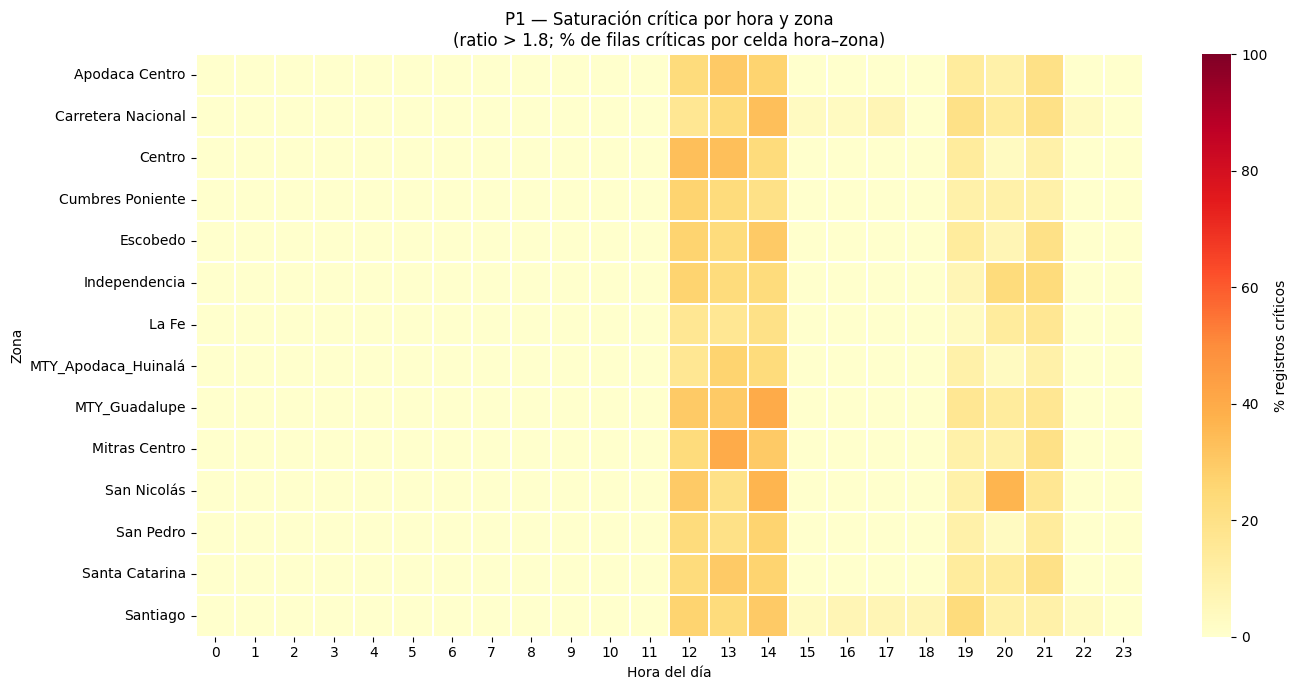

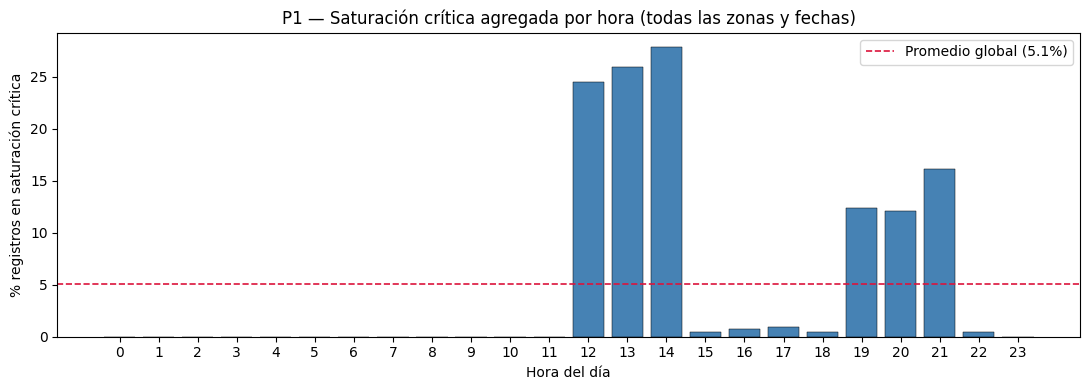


Sobre-oferta por hora del día:


,n_sobre,pct_sobre,ratio_mediana
HOUR,,,
0,420,100.000,0.200
1,142,33.810,0.500
2,130,30.952,0.500
3,148,35.238,0.500
4,140,33.333,0.500
5,145,34.524,0.500
6,142,33.810,0.500
7,420,100.000,0.125
8,30,7.143,0.600



Sobre-oferta por zona (mayor % primero):


,n_sobre,pct_sobre,ratio_mediana
ZONE,,,
Carretera Nacional,281,39.028,0.750
MTY_Apodaca_Huinalá,279,38.750,0.667
Santiago,278,38.611,0.667
San Pedro,186,25.833,0.774
Escobedo,162,22.500,0.900
San Nicolás,148,20.556,0.750
La Fe,145,20.139,1.000
Centro,136,18.889,0.765
MTY_Guadalupe,119,16.528,0.750


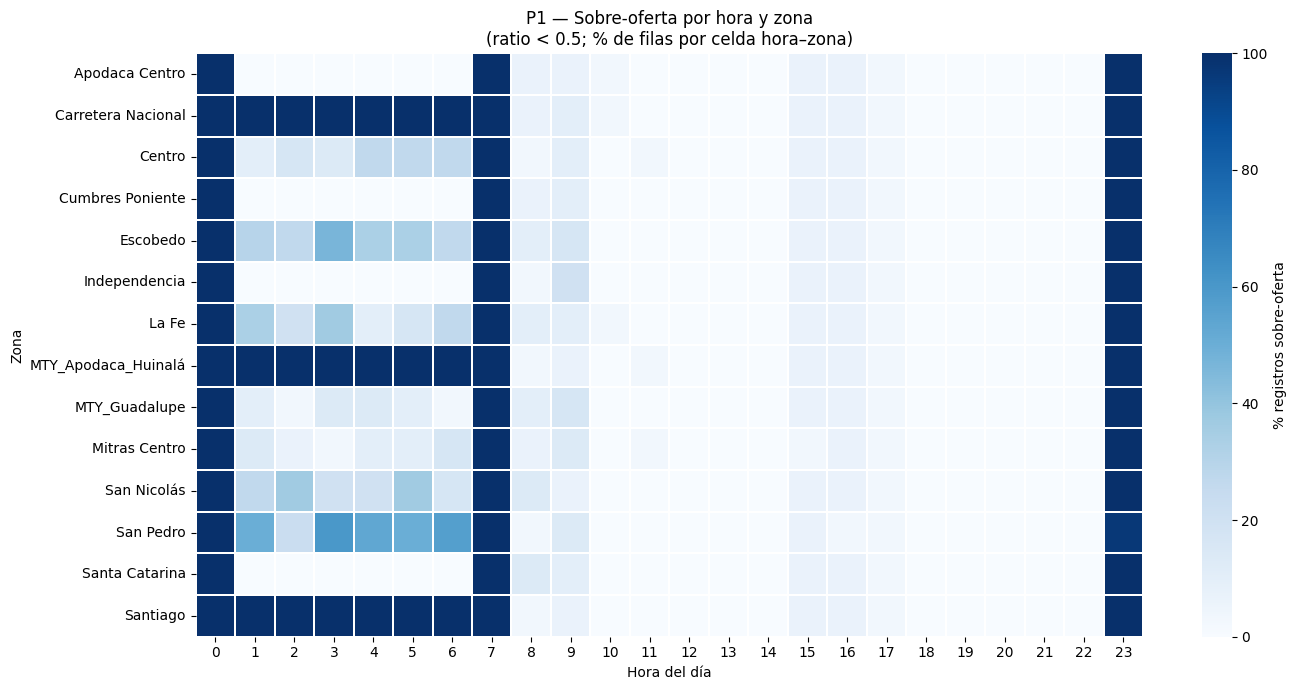

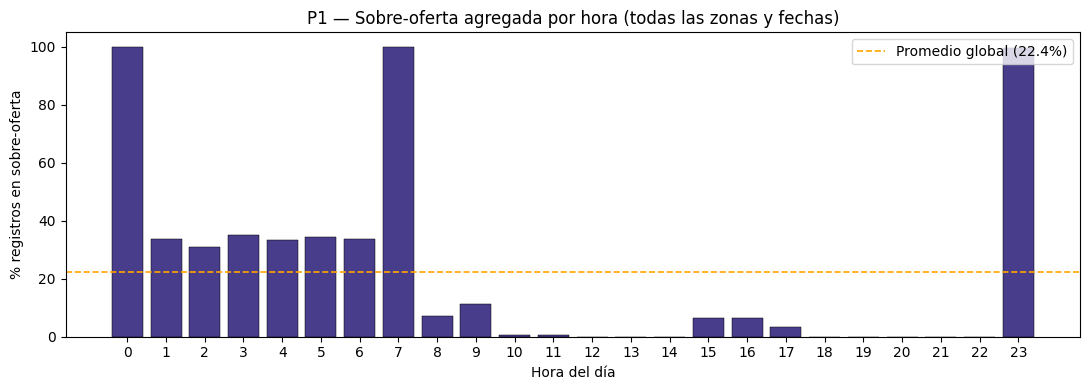

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

UMBRAL_SATURACIÓN = 1.8
UMBRAL_SOBRE_OFERTA = 0.5

rt = df["CONNECTED_RT"].to_numpy()  # Repartidores conectados
order = df["ORDERS"].to_numpy()
ratio = np.where(rt > 0, order / rt, np.where(order > 0, np.inf, np.nan))
df["OPERATIONAL_RATIO"] = ratio
df["CRITICAL_SATURATION"] = (df["OPERATIONAL_RATIO"] > UMBRAL_SATURACIÓN) | np.isinf(
    df["OPERATIONAL_RATIO"]
)
# Sobre-oferta: ratio bajo y finito (inf = saturación extrema, no sobre-oferta)
df["SOBRE_OFERTA"] = np.isfinite(df["OPERATIONAL_RATIO"]) & (
    df["OPERATIONAL_RATIO"] < UMBRAL_SOBRE_OFERTA
)

n_obs = len(df)
n_crit = int(df["CRITICAL_SATURATION"].sum())
pct_global = 100 * n_crit / n_obs
print(f"Observaciones totales: {n_obs}")
print(
    f"En saturación crítica (ratio > {UMBRAL_SATURACIÓN} u órdenes > 0 con CONNECTED_RT = 0): "
    f"{n_crit} ({pct_global:.2f}%)"
)

n_sobre = int(df["SOBRE_OFERTA"].sum())
pct_global_sobre = 100 * n_sobre / n_obs
print(
    f"Sobre-oferta (ratio < {UMBRAL_SOBRE_OFERTA}, ratio finito): "
    f"{n_sobre} ({pct_global_sobre:.2f}%)"
)


def mediana_finita(s):
    x = s.to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    return float(np.nanmedian(x)) if len(x) else np.nan


por_hora = df.groupby("HOUR", sort=True).agg(
    n=("CRITICAL_SATURATION", "size"),
    n_criticas=("CRITICAL_SATURATION", "sum"),
    ratio_mediana=("OPERATIONAL_RATIO", mediana_finita),
)
por_hora["pct_critico"] = 100 * por_hora["n_criticas"] / por_hora["n"]
print("\nPor hora del día (todas las zonas y todos los días):")
display(por_hora[["n_criticas", "pct_critico", "ratio_mediana"]].round(3))

por_zona = df.groupby("ZONE", sort=True).agg(
    n=("CRITICAL_SATURATION", "size"),
    n_criticas=("CRITICAL_SATURATION", "sum"),
    ratio_mediana=("OPERATIONAL_RATIO", mediana_finita),
)
por_zona["pct_critico"] = 100 * por_zona["n_criticas"] / por_zona["n"]
por_zona = por_zona.sort_values("pct_critico", ascending=False)
print("\nPor zona (ordenadas de mayor a menor % crítico):")
display(por_zona[["n_criticas", "pct_critico", "ratio_mediana"]].round(3))

top_hora_zona = (
    df.groupby(["HOUR", "ZONE"], sort=False)
    .agg(pct_critico=("CRITICAL_SATURATION", "mean"))
    .mul(100)
    .sort_values("pct_critico", ascending=False)
    .head(15)
    .round(1)
)
print("\nTop 15 combinaciones hora × zona (% de observaciones críticas en esa celda):")
display(top_hora_zona)

pivot_pct = (
    df.pivot_table(
        index="ZONE",
        columns="HOUR",
        values="CRITICAL_SATURATION",
        aggfunc="mean",
    )
    * 100
)

plt.figure(figsize=(14, 7))
sns.heatmap(
    pivot_pct,
    cmap="YlOrRd",
    vmin=0,
    vmax=100,
    linewidths=0.2,
    linecolor="white",
    cbar_kws={"label": "% registros críticos"},
)
plt.title(
    "P1 — Saturación crítica por hora y zona\n"
    f"(ratio > {UMBRAL_SATURACIÓN}; % de filas críticas por celda hora–zona)"
)
plt.xlabel("Hora del día")
plt.ylabel("Zona")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(
    por_hora.index.astype(int),
    por_hora["pct_critico"],
    color="steelblue",
    edgecolor="black",
    linewidth=0.35,
)
ax.axhline(
    pct_global,
    color="crimson",
    linestyle="--",
    linewidth=1.2,
    label=f"Promedio global ({pct_global:.1f}%)",
)
ax.set_xlabel("Hora del día")
ax.set_ylabel("% registros en saturación crítica")
ax.set_title("P1 — Saturación crítica agregada por hora (todas las zonas y fechas)")
ax.set_xticks(range(0, 24))
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# --- Sobre-oferta: mismos tipos de gráfico (heatmap + barras por hora) ---
por_hora_so = df.groupby("HOUR", sort=True).agg(
    n=("SOBRE_OFERTA", "size"),
    n_sobre=("SOBRE_OFERTA", "sum"),
    ratio_mediana=("OPERATIONAL_RATIO", mediana_finita),
)
por_hora_so["pct_sobre"] = 100 * por_hora_so["n_sobre"] / por_hora_so["n"]
print("\nSobre-oferta por hora del día:")
display(por_hora_so[["n_sobre", "pct_sobre", "ratio_mediana"]].round(3))

por_zona_so = df.groupby("ZONE", sort=True).agg(
    n=("SOBRE_OFERTA", "size"),
    n_sobre=("SOBRE_OFERTA", "sum"),
    ratio_mediana=("OPERATIONAL_RATIO", mediana_finita),
)
por_zona_so["pct_sobre"] = 100 * por_zona_so["n_sobre"] / por_zona_so["n"]
por_zona_so = por_zona_so.sort_values("pct_sobre", ascending=False)
print("\nSobre-oferta por zona (mayor % primero):")
display(por_zona_so[["n_sobre", "pct_sobre", "ratio_mediana"]].round(3))

pivot_sobre = (
    df.pivot_table(
        index="ZONE",
        columns="HOUR",
        values="SOBRE_OFERTA",
        aggfunc="mean",
    )
    * 100
)

plt.figure(figsize=(14, 7))
sns.heatmap(
    pivot_sobre,
    cmap="Blues",
    vmin=0,
    vmax=100,
    linewidths=0.2,
    linecolor="white",
    cbar_kws={"label": "% registros sobre-oferta"},
)
plt.title(
    "P1 — Sobre-oferta por hora y zona\n"
    f"(ratio < {UMBRAL_SOBRE_OFERTA}; % de filas por celda hora–zona)"
)
plt.xlabel("Hora del día")
plt.ylabel("Zona")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(
    por_hora_so.index.astype(int),
    por_hora_so["pct_sobre"],
    color="darkslateblue",
    edgecolor="black",
    linewidth=0.35,
)
ax.axhline(
    pct_global_sobre,
    color="orange",
    linestyle="--",
    linewidth=1.2,
    label=f"Promedio global ({pct_global_sobre:.1f}%)",
)
ax.set_xlabel("Hora del día")
ax.set_ylabel("% registros en sobre-oferta")
ax.set_title("P1 — Sobre-oferta agregada por hora (todas las zonas y fechas)")
ax.set_xticks(range(0, 24))
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()


### 5. Resumen del análisis
- Se obtiene el porcentaje global de observaciones en **saturación crítica** y otro en **sobre-oferta** (órdenes por repartidor muy alto o muy bajo según umbrales del código).
- **Patrones por hora**:
- De 23 a 7 es el lapso de tiempo donde más se presentan escenarios de **sobre-oferta**
- De 12 a 2  y de 19 a 21es el lapso de tiempo donde más se presentan escenarios de **saturación crítica**
- **Mapas de calor por zona** para localizar concentración espacial de cada régimen.

### 6. Conclusiones
P1 permite **priorizar horas y zonas** para despacho de capacidad o incentivos antes de entrar a clima (P2–P3) o política de `EARNINGS` (P4–P5). Los umbrales son **reglas de negocio** explícitas: conviene validarlos con stakeholders y sensibilizarlos si cambia la definición de “crítico”.


### 1. Título 
**Número:** P2 — **Título:** ¿Qué variable externa del dataset se correlaciona con el deterioro del ratio operacional? Describe el mecanismo.

### 2. Descripción
Responder qué **variable externa** del dataset se asocia al **deterioro del ratio** (más órdenes por repartidor). En este archivo la candidata natural es la **precipitación** (`PRECIPITATION_MM`); `EARNINGS` es interna y solo se contrasta como referencia.

### 3. Metodología, herramientas y justificación
Tras normalizar números con coma decimal, se calculan **Pearson** y **Spearman** (lineal vs monótona), a **nivel fila** y **agregado fecha×hora** para reducir pseudorreplicación cuando la lluvia es igual en todas las zonas. **`matplotlib`** (hexbin/scatter) para ver forma de la nube de puntos. La comparación sin lluvia vs con lluvia resume el efecto operativo en medias/medianas.

### 4. Código y decisiones de implementación
Las **dos celdas de código siguientes** primero preparan tipos numéricos y correlaciones; la segunda grafica. La agregación `DATE×HOUR` es la referencia principal para correlaciones globales según la nota metodológica en comentarios del notebook.


In [39]:
'''
Función para convertir datos a tipo float y puedanejecutarse operaciones. 
'''
def coma_a_float(series):
    return pd.to_numeric(
        series.astype(str).str.replace(",", ".", regex=False), errors="coerce"
    )


df["precip_mm"] = coma_a_float(df["PRECIPITATION_MM"])
df["earnings_num"] = coma_a_float(df["EARNINGS"])

sub = df[np.isfinite(df["OPERATIONAL_RATIO"])].copy()
print(
    f"Filas con ratio finito (se excluye inf cuando hay órdenes y 0 repartidores): "
    f"{len(sub)} / {len(df)}"
)
print(
    f"Precipitación: {int((sub['precip_mm'] == 0).sum())} filas en 0 mm; "
    f"{int((sub['precip_mm'] > 0).sum())} filas con > 0 mm\n"
)

r_pear = sub["OPERATIONAL_RATIO"].corr(sub["precip_mm"], method="pearson")
r_spear = sub["OPERATIONAL_RATIO"].corr(sub["precip_mm"], method="spearman")
print(
    "Nivel fila (zona × día × hora) — correlación ratio vs precipitación:\n"
    f"  Pearson:  {r_pear:.4f}\n"
    f"  Spearman: {r_spear:.4f}\n"
    f"  n = {len(sub)}"
)

r_earn = sub["OPERATIONAL_RATIO"].corr(sub["earnings_num"], method="spearman")
print(
    f"\nReferencia interna — Spearman ratio vs EARNINGS: {r_earn:.4f} "
    "(no es variable externa)\n"
)


def mean_finite_series(s):
    x = s.to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    return float(np.nanmean(x)) if len(x) else np.nan


agg = (
    df.groupby(["DATE", "HOUR"], as_index=False)
    .agg(
        precip_mm=("precip_mm", "first"),
        ratio_media_zonas=("OPERATIONAL_RATIO", mean_finite_series),
    )
)
agg_sub = agg.dropna(subset=["ratio_media_zonas", "precip_mm"])
agg_pear = agg_sub["ratio_media_zonas"].corr(agg_sub["precip_mm"], method="pearson")
agg_spear = agg_sub["ratio_media_zonas"].corr(agg_sub["precip_mm"], method="spearman")
print(
    "Nivel agregado (fecha × hora; media del ratio entre zonas) — "
    "menos pseudorreplicación que el nivel fila:\n"
    f"  Pearson:  {agg_pear:.4f}\n"
    f"  Spearman: {agg_spear:.4f}\n"
    f"  n = {len(agg_sub)}"
)

sec = sub.loc[sub["precip_mm"] == 0, "OPERATIONAL_RATIO"]
lluv = sub.loc[sub["precip_mm"] > 0, "OPERATIONAL_RATIO"]
print("\nRatio operacional — nivel fila, sin lluvia vs con lluvia:")
display(
    pd.DataFrame(
        {
            "n": [len(sec), len(lluv)],
            "media": [sec.mean(), lluv.mean()],
            "mediana": [sec.median(), lluv.median()],
        },
        index=["0 mm", "> 0 mm"],
    ).round(4)
)

a_sec = agg_sub.loc[agg_sub["precip_mm"] == 0, "ratio_media_zonas"]
a_lluv = agg_sub.loc[agg_sub["precip_mm"] > 0, "ratio_media_zonas"]
print("Ratio medio entre zonas — agregado fecha × hora:")
display(
    pd.DataFrame(
        {
            "n": [len(a_sec), len(a_lluv)],
            "media": [a_sec.mean(), a_lluv.mean()],
            "mediana": [a_sec.median(), a_lluv.median()],
        },
        index=["0 mm", "> 0 mm"],
    ).round(4)
)

Filas con ratio finito (se excluye inf cuando hay órdenes y 0 repartidores): 10080 / 10080
Precipitación: 9464 filas en 0 mm; 616 filas con > 0 mm

Nivel fila (zona × día × hora) — correlación ratio vs precipitación:
  Pearson:  0.3189
  Spearman: 0.2307
  n = 10080

Referencia interna — Spearman ratio vs EARNINGS: 0.0761 (no es variable externa)

Nivel agregado (fecha × hora; media del ratio entre zonas) — menos pseudorreplicación que el nivel fila:
  Pearson:  0.3617
  Spearman: 0.2401
  n = 720

Ratio operacional — nivel fila, sin lluvia vs con lluvia:


,n,media,mediana
0 mm,9464,0.7749,0.7778
> 0 mm,616,1.4782,1.3333


Ratio medio entre zonas — agregado fecha × hora:


,n,media,mediana
0 mm,676,0.7749,0.7559
> 0 mm,44,1.4782,1.4096


/var/folders/sd/vrjwt23d39s1ymw5vbmg_p680000gn/T/ipykernel_57243/2585609260.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="lluvia", y="OPERATIONAL_RATIO", ax=ax, palette="Set2")


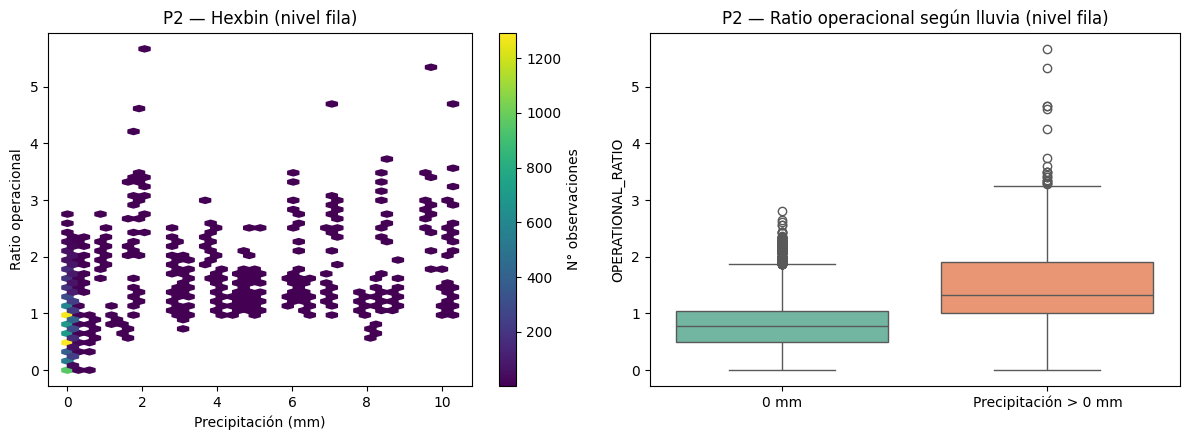

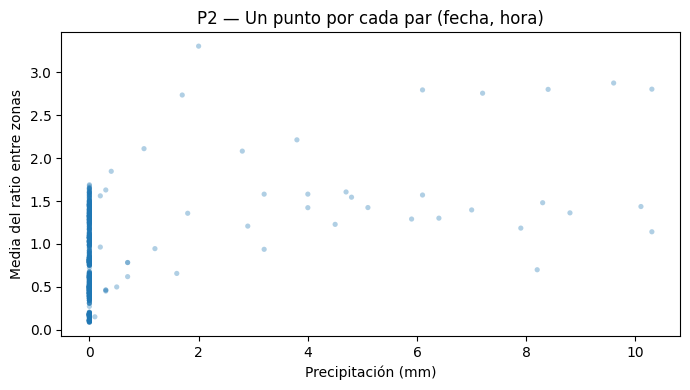

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
hb = ax.hexbin(
    sub["precip_mm"],
    sub["OPERATIONAL_RATIO"],
    gridsize=(35, 35),
    mincnt=1,
    cmap="viridis",
)
plt.colorbar(hb, ax=ax, label="N° observaciones")
ax.set_xlabel("Precipitación (mm)")
ax.set_ylabel("Ratio operacional")
ax.set_title("P2 — Hexbin (nivel fila)")

ax = axes[1]
plot_df = sub.assign(
    lluvia=np.where(sub["precip_mm"] > 0, "Precipitación > 0 mm", "0 mm")
)
sns.boxplot(data=plot_df, x="lluvia", y="OPERATIONAL_RATIO", ax=ax, palette="Set2")
ax.set_xlabel("")
ax.set_title("P2 — Ratio operacional según lluvia (nivel fila)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(
    agg_sub["precip_mm"],
    agg_sub["ratio_media_zonas"],
    alpha=0.35,
    s=14,
    edgecolors="none",
)
ax.set_xlabel("Precipitación (mm)")
ax.set_ylabel("Media del ratio entre zonas")
ax.set_title("P2 — Un punto por cada par (fecha, hora)")
plt.tight_layout()
plt.show()

### 5. Resumen del análisis
- **Respuesta a la pregunta:** la única variable **externa** en el dataset es la **precipitación** (`PRECIPITATION_MM`). Es la candidata natural para relacionar con el **ratio operacional** y con el **deterioro** (subidas del ratio hacia saturación).

- **Cómo leer los números:** mira el **signo** de Pearson y Spearman en la salida anterior. Un coeficiente **positivo** indica que, en promedio, **más lluvia va acompañado de un ratio más alto** (más órdenes por repartidor conectado), alineado con el mecanismo descrito (demanda u oferta de repartidores). Un valor **cercano a cero** sugiere **poca asociación lineal o monótona** en este periodo.

- **Nivel fila vs agregado:** el nivel **fecha × hora** resume todas las zonas y reduce el peso de tener muchas filas con la misma precipitación. Suele ser la referencia principal para correlación; el nivel fila puede **inflar** la confianza aparente porque muchas filas comparten el mismo valor de lluvia.

- **Limitaciones:** muchas observaciones pueden tener **0 mm**; la variación restante puede ser **pequeña**. **Hora del día** y **día del mes** pueden estar mezcladas con el clima (confusión / variables omitidas). La correlación **no demuestra causalidad**; solo describe co-movimiento en los datos observados.

- **Contraste con EARNINGS:** si la correlación ratio–earnings es fuerte, recuerda que los incentivos son **decisión interna**; no sustituyen la respuesta sobre factores **externos**.

Complementa con coeficientes y gráficos: correlación **positiva** entre precipitación y ratio indica co-movimiento con **mayor estrés operativo** bajo lluvia en esta ventana de datos.

### 6. Conclusiones
La única variable **externa** candidata en el CSV es la **precipitación**; la relación reportada es **no causal** y debe leerse junto con la agregación **fecha×hora** y las heterogeneidades de **zona** (P3). `EARNINGS` no sustituye a un factor externo en la respuesta conceptual de P2.


### 1. Título 
**Número:** P3 — **Título:** ¿Todas las zonas responden igual a esa variable? Identifica las más vulnerables y explica por qué tienen mayor sensibilidad.

### 2. Descripción
Evaluar **heterogeneidad espacial**: si algunas **zonas** amplían más el ratio ante lluvia que otras (mayor “vulnerabilidad” operativa al clima). Complementa P2, que es global.

### 3. Metodología, herramientas y justificación
Por **zona**: diferencia de medianas entre 0 mm y >0 mm, **Spearman/Pearson** locales y pendiente simple del ratio vs mm. **`pandas`** para tablas de ranking; **`matplotlib`/`seaborn`** para barras de sensibilidad y comparación de distribuciones en las zonas más marcadas.

### 4. Código y decisiones de implementación
En la **siguiente celda**: construcción de tablas de vulnerabilidad, ordenamiento por `delta_mediana` u otras métricas definidas en código, y figuras que priorizan zonas extremas para lectura ejecutiva.


Top zonas más vulnerables (mayor aumento del ratio con lluvia):


,n,n_lluvia,mediana_0mm,mediana_lluvia,delta_mediana,spearman,pearson,slope_ratio_por_mm
ZONE,,,,,,,,
Santiago,720,44,0.6667,1.6667,1.0000,0.2730,0.4628,0.2672
Carretera Nacional,720,44,0.7143,1.5417,0.8274,0.2719,0.3952,0.2135
Cumbres Poniente,720,44,0.7273,1.3750,0.6477,0.2214,0.2797,0.1081
MTY_Guadalupe,720,44,0.7143,1.3000,0.5857,0.2351,0.2937,0.1178
Santa Catarina,720,44,0.9282,1.5000,0.5718,0.2420,0.3785,0.1475
MTY_Apodaca_Huinalá,720,44,0.6667,1.2361,0.5694,0.2235,0.3166,0.1594
San Pedro,720,44,0.7500,1.2926,0.5426,0.2282,0.3059,0.1239
Escobedo,720,44,0.8750,1.4000,0.5250,0.2192,0.2798,0.1201



Top zonas menos sensibles o con caída del ratio con lluvia (delta más bajo):


,n,n_lluvia,mediana_0mm,mediana_lluvia,delta_mediana,spearman,pearson,slope_ratio_por_mm
ZONE,,,,,,,,
San Pedro,720,44,0.7500,1.2926,0.5426,0.2282,0.3059,0.1239
Escobedo,720,44,0.8750,1.4000,0.5250,0.2192,0.2798,0.1201
San Nicolás,720,44,0.6847,1.1909,0.5063,0.2134,0.2892,0.1203
Centro,720,44,0.7273,1.2265,0.4992,0.2278,0.2993,0.1116
Independencia,720,44,0.8000,1.2900,0.4900,0.2382,0.3202,0.1214
Mitras Centro,720,44,0.7500,1.2271,0.4771,0.2239,0.2766,0.1088
Apodaca Centro,720,44,0.8000,1.2614,0.4614,0.2124,0.3037,0.1193
La Fe,720,44,0.9024,1.3137,0.4113,0.2279,0.2673,0.1055


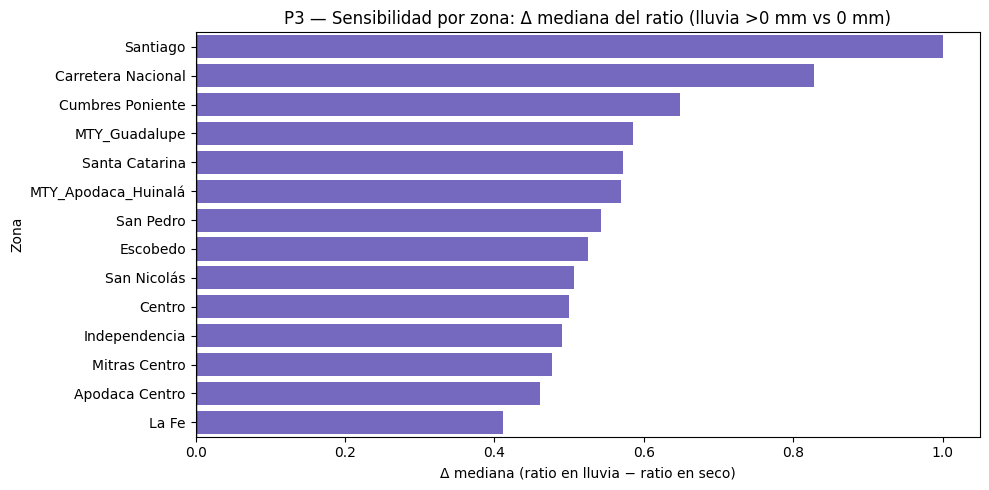

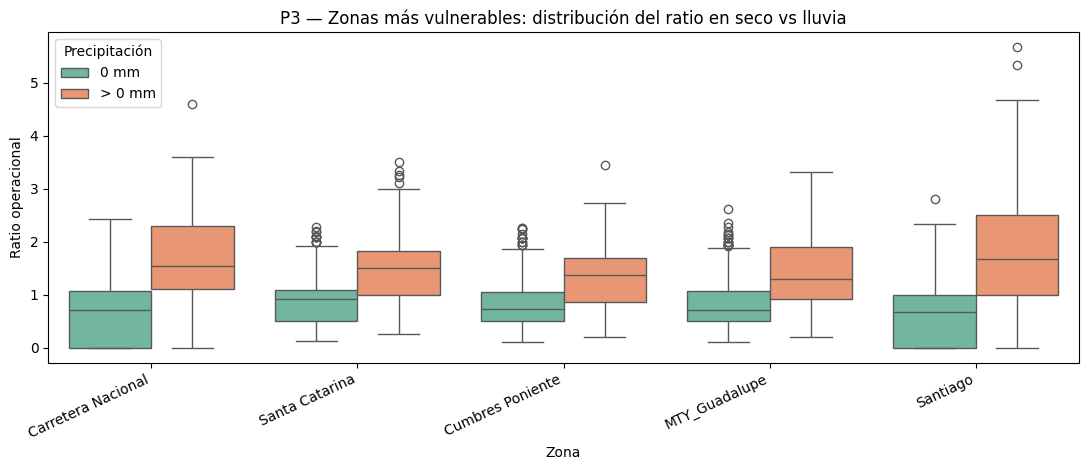

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Reusar 'sub' si ya existe por P2; si no, construirlo aquí
if "sub" not in globals():
    if "precip_mm" not in df.columns:
        def coma_a_float(series):
            return pd.to_numeric(
                series.astype(str).str.replace(",", ".", regex=False), errors="coerce"
            )
        df["precip_mm"] = coma_a_float(df["PRECIPITATION_MM"])

    if "OPERATIONAL_RATIO" not in df.columns:
        rt = df["CONNECTED_RT"].to_numpy()
        order = df["ORDERS"].to_numpy()
        df["OPERATIONAL_RATIO"] = np.where(
            rt > 0, order / rt, np.where(order > 0, np.inf, np.nan)
        )

    sub = df[np.isfinite(df["OPERATIONAL_RATIO"])].copy()

sub = sub.dropna(subset=["precip_mm", "OPERATIONAL_RATIO", "ZONE"]).copy()
sub["lluvia_bin"] = np.where(sub["precip_mm"] > 0, "> 0 mm", "0 mm")


def slope_ols(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    x = x[m]
    y = y[m]
    if len(x) < 3:
        return np.nan
    vx = np.var(x)
    if vx == 0:
        return np.nan
    return float(np.cov(x, y, bias=True)[0, 1] / vx)


res = []
for zone, g in sub.groupby("ZONE"):
    seco = g.loc[g["lluvia_bin"] == "0 mm", "OPERATIONAL_RATIO"]
    lluv = g.loc[g["lluvia_bin"] == "> 0 mm", "OPERATIONAL_RATIO"]

    med_seco = float(seco.median()) if len(seco) else np.nan
    med_lluv = float(lluv.median()) if len(lluv) else np.nan
    delta_med = med_lluv - med_seco

    spear = g["OPERATIONAL_RATIO"].corr(g["precip_mm"], method="spearman")
    pear = g["OPERATIONAL_RATIO"].corr(g["precip_mm"], method="pearson")
    slope = slope_ols(g["precip_mm"], g["OPERATIONAL_RATIO"])

    res.append(
        {
            "ZONE": zone,
            "n": len(g),
            "n_lluvia": int((g["precip_mm"] > 0).sum()),
            "mediana_0mm": med_seco,
            "mediana_lluvia": med_lluv,
            "delta_mediana": delta_med,
            "spearman": spear,
            "pearson": pear,
            "slope_ratio_por_mm": slope,
        }
    )

p3 = pd.DataFrame(res)
# "Vulnerable" = gran aumento del ratio con lluvia (delta_mediana alto)
p3 = p3.sort_values("delta_mediana", ascending=False)

print("Top zonas más vulnerables (mayor aumento del ratio con lluvia):")
display(p3.head(8).set_index("ZONE").round(4))

print("\nTop zonas menos sensibles o con caída del ratio con lluvia (delta más bajo):")
display(p3.tail(8).set_index("ZONE").round(4))

# Gráfico 1: ranking de sensibilidad (delta de mediana)
plt.figure(figsize=(10, 5))
sns.barplot(
    data=p3,
    y="ZONE",
    x="delta_mediana",
    color="slateblue",
)
plt.axvline(0, color="black", linewidth=1)
plt.title("P3 — Sensibilidad por zona: Δ mediana del ratio (lluvia >0 mm vs 0 mm)")
plt.xlabel("Δ mediana (ratio en lluvia − ratio en seco)")
plt.ylabel("Zona")
plt.tight_layout()
plt.show()

# Gráfico 2: comparación directa de distribuciones para las zonas más vulnerables
zonas_top = p3.head(5)["ZONE"].tolist()
plot_top = sub[sub["ZONE"].isin(zonas_top)].copy()
plt.figure(figsize=(11, 4.8))
sns.boxplot(
    data=plot_top,
    x="ZONE",
    y="OPERATIONAL_RATIO",
    hue="lluvia_bin",
    palette="Set2",
)
plt.title("P3 — Zonas más vulnerables: distribución del ratio en seco vs lluvia")
plt.xlabel("Zona")
plt.ylabel("Ratio operacional")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Precipitación")
plt.tight_layout()
plt.show()

### 5. Resumen del análisis
La tabla y gráficos de P3 ordenan zonas por **sensibilidad** al pasar de sereno a lluvia (delta de medianas, correlaciones locales, pendientes). No todas las zonas deberían comportarse igual si la geografía y la demanda difieren.

### 6. Conclusiones
Si existen **zonas “vulnerables”** claras, las políticas de capacidad/incentivos pueden **diferenciarse por polígono** en día de lluvia en lugar de una respuesta única. Validar con volumen de pedidos y estabilidad estadística (poca lluvia en alguna zona puede dar estimaciones ruidosas).


### 1. Título 
**Número:** P4 — **Título:** ¿El nivel de earnings (incentivos) está bien calibrado a lo largo del mes? ¿Detectas periodos con gasto ineficiente? Muestra los días exactos.

### 2. Descripción
Analizar **incentivos diarios**: gasto total, costo aproximado por orden y coherencia con **señales operativas** del mismo día (ratio agregado, % crítico, % sobre-oferta). Objetivo: detectar **días** donde el gasto sea alto en contextos de sobre-oferta (posible mala focalización) frente a días con saturación (gasto posiblemente reactivo).

### 3. Metodología, herramientas y justificación
Agregación **`groupby('DATE')`**, métricas derivadas y banderas heurísticas; **`seaborn`** para series y scatter con codificación de color/tamaño. La heurística es **diagnóstica**, no prueba causal.

### 4. Código y decisiones de implementación
En la **siguiente celda**: normalización de `earnings`, construcción de `posible_ineficiencia` y umbrales de “días extremos” según comentarios; gráficos ordenan el tiempo y destacan outliers operativos.


Resumen diario (ordenado por fecha):


,DATE,earnings_total,orders_total,connected_total,ratio_dia,earnings_por_orden,pct_critico,pct_sobre,posible_ineficiencia
0,2024-03-01,19013.4,3126,2959,1.0564,6.0823,4.7619,19.6429,False
1,2024-03-02,19058.6,3070,3028,1.0139,6.2080,2.6786,21.7262,False
2,2024-03-03,20411.5,3097,3374,0.9179,6.5907,3.5714,28.8690,True
3,2024-03-04,19011.5,3109,3009,1.0332,6.1150,3.8690,22.0238,False
4,2024-03-05,19210.1,3334,2855,1.1678,5.7619,9.5238,20.5357,False
5,2024-03-06,19190.7,3165,3084,1.0263,6.0634,4.4643,20.2381,False
6,2024-03-07,20073.4,3095,3319,0.9325,6.4858,3.2738,29.4643,True
7,2024-03-08,18889.3,3358,2764,1.2149,5.6252,13.9881,21.7262,False
8,2024-03-09,19185.3,3142,3065,1.0251,6.1061,3.5714,21.1310,False
9,2024-03-10,19149.5,3134,3060,1.0242,6.1102,3.8690,22.0238,False



Días marcados como posible gasto ineficiente (fechas exactas):


,DATE,earnings_total,orders_total,connected_total,pct_critico,pct_sobre,ratio_dia,earnings_por_orden,posible_ineficiencia
0,2024-03-22,20517.6,3096,3433,3.8690,34.8214,0.9018,6.6271,True
1,2024-03-03,20411.5,3097,3374,3.5714,28.8690,0.9179,6.5907,True
2,2024-03-07,20073.4,3095,3319,3.2738,29.4643,0.9325,6.4858,True



Top 10 días por earnings_total (para inspección):


,DATE,earnings_total,orders_total,connected_total,pct_critico,pct_sobre,ratio_dia,earnings_por_orden,posible_ineficiencia
11,2024-03-12,20877.9,3491,3503,3.5714,21.4286,0.9966,5.9805,False
21,2024-03-22,20517.6,3096,3433,3.8690,34.8214,0.9018,6.6271,True
2,2024-03-03,20411.5,3097,3374,3.5714,28.8690,0.9179,6.5907,True
13,2024-03-14,20309.5,3111,3354,5.0595,27.9762,0.9275,6.5283,False
19,2024-03-20,20177.1,3347,3274,2.6786,21.1310,1.0223,6.0284,False
6,2024-03-07,20073.4,3095,3319,3.2738,29.4643,0.9325,6.4858,True
14,2024-03-15,19994.3,3303,3150,2.0833,21.4286,1.0486,6.0534,False
10,2024-03-11,19279.0,3116,3068,4.4643,21.1310,1.0156,6.1871,False
18,2024-03-19,19222.0,3106,3078,4.1667,21.4286,1.0091,6.1887,False
28,2024-03-29,19213.2,3114,3113,2.6786,20.2381,1.0003,6.1699,False



Top 10 días por earnings_por_orden (costo por orden):


,DATE,earnings_total,orders_total,connected_total,pct_critico,pct_sobre,ratio_dia,earnings_por_orden,posible_ineficiencia
21,2024-03-22,20517.6,3096,3433,3.8690,34.8214,0.9018,6.6271,True
2,2024-03-03,20411.5,3097,3374,3.5714,28.8690,0.9179,6.5907,True
13,2024-03-14,20309.5,3111,3354,5.0595,27.9762,0.9275,6.5283,False
6,2024-03-07,20073.4,3095,3319,3.2738,29.4643,0.9325,6.4858,True
1,2024-03-02,19058.6,3070,3028,2.6786,21.7262,1.0139,6.2080,False
18,2024-03-19,19222.0,3106,3078,4.1667,21.4286,1.0091,6.1887,False
10,2024-03-11,19279.0,3116,3068,4.4643,21.1310,1.0156,6.1871,False
29,2024-03-30,19182.5,3109,3075,3.5714,22.9167,1.0111,6.1700,False
28,2024-03-29,19213.2,3114,3113,2.6786,20.2381,1.0003,6.1699,False
22,2024-03-23,19149.8,3104,3080,3.5714,21.7262,1.0078,6.1694,False


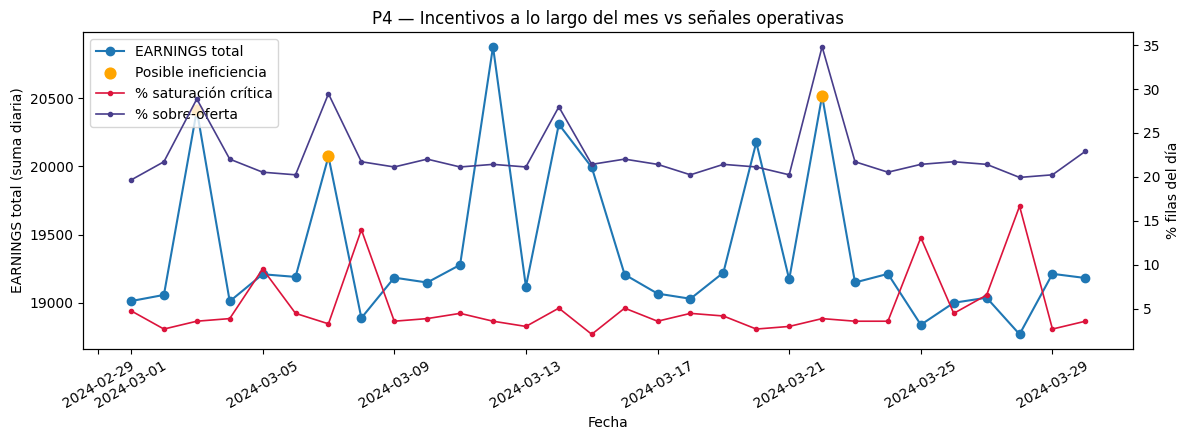

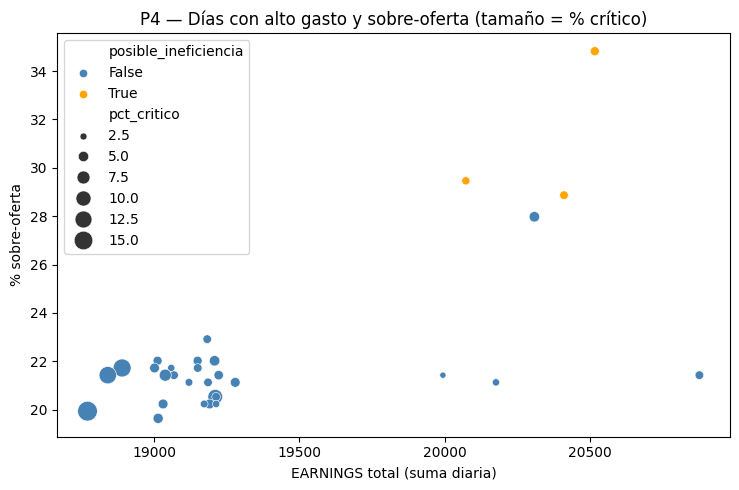

In [42]:
# Asegurar columnas numéricas y flags (reusar si ya existen)
if "earnings_num" not in df.columns:
    def coma_a_float(series):
        return pd.to_numeric(
            series.astype(str).str.replace(",", ".", regex=False), errors="coerce"
        )
    df["earnings_num"] = coma_a_float(df["EARNINGS"])

if "OPERATIONAL_RATIO" not in df.columns:
    rt = df["CONNECTED_RT"].to_numpy()
    order = df["ORDERS"].to_numpy()
    df["OPERATIONAL_RATIO"] = np.where(
        rt > 0, order / rt, np.where(order > 0, np.inf, np.nan)
    )

UMBRAL_SATURACIÓN = 1.8
UMBRAL_SOBRE_OFERTA = 0.5

if "CRITICAL_SATURATION" not in df.columns:
    df["CRITICAL_SATURATION"] = (df["OPERATIONAL_RATIO"] > UMBRAL_SATURACIÓN) | np.isinf(
        df["OPERATIONAL_RATIO"]
    )

if "SOBRE_OFERTA" not in df.columns:
    df["SOBRE_OFERTA"] = np.isfinite(df["OPERATIONAL_RATIO"]) & (
        df["OPERATIONAL_RATIO"] < UMBRAL_SOBRE_OFERTA
    )

# Fecha a datetime para ordenar bien
p4_df = df.copy()
p4_df["DATE"] = pd.to_datetime(p4_df["DATE"], errors="coerce")

# Agregado diario
by_day = (
    p4_df.groupby("DATE", as_index=False)
    .agg(
        earnings_total=("earnings_num", "sum"),
        orders_total=("ORDERS", "sum"),
        connected_total=("CONNECTED_RT", "sum"),
        pct_critico=("CRITICAL_SATURATION", "mean"),
        pct_sobre=("SOBRE_OFERTA", "mean"),
    )
)
by_day["pct_critico"] *= 100
by_day["pct_sobre"] *= 100
by_day["ratio_dia"] = np.where(
    by_day["connected_total"] > 0,
    by_day["orders_total"] / by_day["connected_total"],
    np.nan,
)
by_day["earnings_por_orden"] = np.where(
    by_day["orders_total"] > 0,
    by_day["earnings_total"] / by_day["orders_total"],
    np.nan,
)

# Umbrales para "días extremos" (ajustables)
q_earn = by_day["earnings_total"].quantile(0.75)
q_cpo = by_day["earnings_por_orden"].quantile(0.75)

by_day["posible_ineficiencia"] = (
    (by_day["earnings_total"] >= q_earn) | (by_day["earnings_por_orden"] >= q_cpo)
) & (by_day["pct_sobre"] >= 25) & (by_day["pct_critico"] <= 5)

print("Resumen diario (ordenado por fecha):")
display(
    by_day.sort_values("DATE")[
        [
            "DATE",
            "earnings_total",
            "orders_total",
            "connected_total",
            "ratio_dia",
            "earnings_por_orden",
            "pct_critico",
            "pct_sobre",
            "posible_ineficiencia",
        ]
    ].round(4)
)

print("\nDías marcados como posible gasto ineficiente (fechas exactas):")
display(
    by_day[by_day["posible_ineficiencia"]]
    .sort_values(["earnings_por_orden", "earnings_total"], ascending=False)
    .reset_index(drop=True)
    .round(4)
)

print("\nTop 10 días por earnings_total (para inspección):")
display(by_day.sort_values("earnings_total", ascending=False).head(10).round(4))

print("\nTop 10 días por earnings_por_orden (costo por orden):")
display(by_day.sort_values("earnings_por_orden", ascending=False).head(10).round(4))

# Gráfica 1: serie temporal de earnings_total y señales operativas
fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.plot(by_day["DATE"], by_day["earnings_total"], marker="o", linewidth=1.5, label="EARNINGS total")
ax1.set_ylabel("EARNINGS total (suma diaria)")
ax1.set_xlabel("Fecha")
ax1.tick_params(axis="x", rotation=30)

ax2 = ax1.twinx()
ax2.plot(by_day["DATE"], by_day["pct_critico"], color="crimson", marker=".", linewidth=1.2, label="% saturación crítica")
ax2.plot(by_day["DATE"], by_day["pct_sobre"], color="darkslateblue", marker=".", linewidth=1.2, label="% sobre-oferta")
ax2.set_ylabel("% filas del día")

# Marcar días potencialmente ineficientes
inef = by_day[by_day["posible_ineficiencia"]]
ax1.scatter(inef["DATE"], inef["earnings_total"], color="orange", s=60, zorder=5, label="Posible ineficiencia")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.title("P4 — Incentivos a lo largo del mes vs señales operativas")
plt.tight_layout()
plt.show()

# Gráfica 2: scatter para detectar días outlier (gasto vs desempeño)
plt.figure(figsize=(7.5, 5))
sns.scatterplot(
    data=by_day,
    x="earnings_total",
    y="pct_sobre",
    size="pct_critico",
    sizes=(20, 200),
    hue="posible_ineficiencia",
    palette={False: "steelblue", True: "orange"},
)
plt.title("P4 — Días con alto gasto y sobre-oferta (tamaño = % crítico)")
plt.xlabel("EARNINGS total (suma diaria)")
plt.ylabel("% sobre-oferta")
plt.tight_layout()
plt.show()

### 5. Resumen del análisis
El resumen diario muestra **EARNINGS** agregados, órdenes, repartidores conectados, ratio del día, costo por orden y proporciones de régimen crítico/sobre-oferta. Los scatter y series marcan días con **posible ineficiencia** según la heurística del código (alto gasto con mucha sobre-oferta y poca saturación crítica, u otras reglas implementadas).

### 6. Conclusiones
**Calibración** de incentivos se evalúa mejor **junto al estado operativo del mismo día**: gasto alto no es intrínsecamente malo si coincide con **estrés** real. Los días etiquetados como candidatos a revisión merecen **investigación cualitativa** (campañas, eventos, calidad de datos).


### 1. Título 
**Número:** P5 — **Título:** ¿Qué relación tiene el nivel de earnings con la saturación operacional? ¿Es una relación simple o depende de otras condiciones?

### 2. Descripción
Explorar si mayor **EARNINGS** acompaña mejor o peor **ratio** y mayor proporción de **saturación crítica**, y si eso cambia bajo **lluvia** o por **franja horaria**. Aclarar límites de interpretación por **endogeneidad** (los incentivos suelen subir cuando la operación ya está tensa).

### 3. Metodología, herramientas y justificación
Correlaciones **Spearman** a nivel fila y en agregados `DATE×HOUR`; segmentación por bin de lluvia y por bloques horarios; visualizaciones tipo scatter y barras por quintiles. **`pandas`** + **`seaborn`** mantienen el mismo estilo analítico que el resto del módulo.

### 4. Código y decisiones de implementación
En la **siguiente celda**: reuso de columnas ya calculadas cuando existen, agregaciones para evitar pseudorreplicación y gráficos que separan efectos por contexto (lluvia, hora). Revisa avisos de correlación constante en algunos subgrupos (muestra chica o sin variación).


Correlación (nivel fila, ratio finito):
  Spearman(EARNINGS, ratio): 0.0761
  Spearman(EARNINGS, CRITICAL_SATURATION): -0.1009

Correlación (agregado DATE×HOUR):
  Spearman(EARNINGS_total, ratio_agg): 0.434
  Spearman(EARNINGS_total, pct_critico): 0.6157

Segmentación por lluvia (agregado DATE×HOUR):


,lluvia_bin,n,spearman_earn_vs_ratio,spearman_earn_vs_pctcrit
0,0 mm,676.0,0.3868,0.6301
1,> 0 mm,44.0,-0.2624,-0.4493



Segmentación por bloque horario (agregado DATE×HOUR):


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/nanops.py:1569: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pandas/core/nanops.py:1569: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


,bloque_hora,n,spearman_earn_vs_ratio,spearman_earn_vs_pctcrit
0,madrugada(0-6),210.0,-0.1391,NaN
1,mañana(7-10),120.0,-0.2214,NaN
2,tarde(11-16),180.0,0.4483,0.5431
3,noche(17-23),210.0,0.5584,0.5600


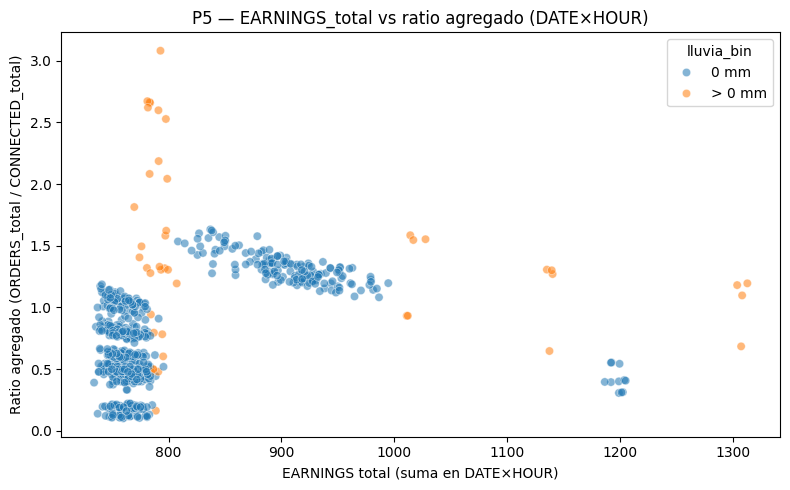

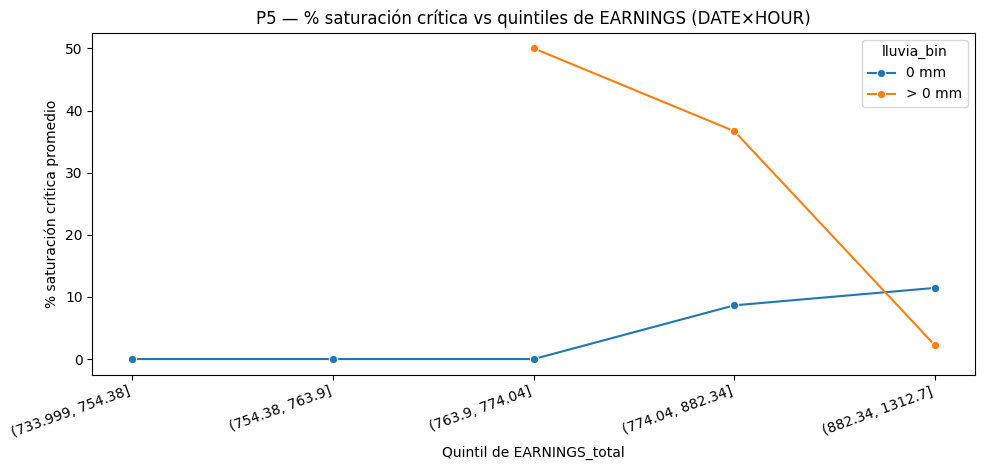

In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Asegurar columnas clave
if "earnings_num" not in df.columns:
    def coma_a_float(series):
        return pd.to_numeric(
            series.astype(str).str.replace(",", ".", regex=False), errors="coerce"
        )
    df["earnings_num"] = coma_a_float(df["EARNINGS"])

if "precip_mm" not in df.columns:
    def coma_a_float(series):
        return pd.to_numeric(
            series.astype(str).str.replace(",", ".", regex=False), errors="coerce"
        )
    df["precip_mm"] = coma_a_float(df["PRECIPITATION_MM"])

if "OPERATIONAL_RATIO" not in df.columns:
    rt = df["CONNECTED_RT"].to_numpy()
    order = df["ORDERS"].to_numpy()
    df["OPERATIONAL_RATIO"] = np.where(
        rt > 0, order / rt, np.where(order > 0, np.inf, np.nan)
    )

UMBRAL_SATURACIÓN = 1.8
if "CRITICAL_SATURATION" not in df.columns:
    df["CRITICAL_SATURATION"] = (df["OPERATIONAL_RATIO"] > UMBRAL_SATURACIÓN) | np.isinf(
        df["OPERATIONAL_RATIO"]
    )

# Nivel fila (zona×fecha×hora) — usar ratio finito
p5 = df.copy()
p5 = p5[np.isfinite(p5["OPERATIONAL_RATIO"])].dropna(
    subset=["earnings_num", "precip_mm", "OPERATIONAL_RATIO", "HOUR"]
)
p5["lluvia_bin"] = np.where(p5["precip_mm"] > 0, "> 0 mm", "0 mm")

print("Correlación (nivel fila, ratio finito):")
print(
    "  Spearman(EARNINGS, ratio):",
    round(p5["earnings_num"].corr(p5["OPERATIONAL_RATIO"], method="spearman"), 4),
)
print(
    "  Spearman(EARNINGS, CRITICAL_SATURATION):",
    round(p5["earnings_num"].corr(p5["CRITICAL_SATURATION"].astype(int), method="spearman"), 4),
)

# Agregado (DATE×HOUR): reduce pseudorreplicación
p5_agg = (
    p5.assign(DATE=pd.to_datetime(p5["DATE"], errors="coerce"))
    .groupby(["DATE", "HOUR"], as_index=False)
    .agg(
        earnings_total=("earnings_num", "sum"),
        orders_total=("ORDERS", "sum"),
        connected_total=("CONNECTED_RT", "sum"),
        pct_critico=("CRITICAL_SATURATION", "mean"),
        precip_mm=("precip_mm", "first"),
    )
)
p5_agg["pct_critico"] *= 100
p5_agg["ratio_agg"] = np.where(
    p5_agg["connected_total"] > 0,
    p5_agg["orders_total"] / p5_agg["connected_total"],
    np.nan,
)
p5_agg["lluvia_bin"] = np.where(p5_agg["precip_mm"] > 0, "> 0 mm", "0 mm")

print("\nCorrelación (agregado DATE×HOUR):")
print(
    "  Spearman(EARNINGS_total, ratio_agg):",
    round(p5_agg["earnings_total"].corr(p5_agg["ratio_agg"], method="spearman"), 4),
)
print(
    "  Spearman(EARNINGS_total, pct_critico):",
    round(p5_agg["earnings_total"].corr(p5_agg["pct_critico"], method="spearman"), 4),
)

# --- ¿Depende de condiciones? ---
# 1) Por lluvia
seg_lluvia = (
    p5_agg.groupby("lluvia_bin")
    .apply(
        lambda g: pd.Series(
            {
                "n": len(g),
                "spearman_earn_vs_ratio": g["earnings_total"].corr(g["ratio_agg"], method="spearman"),
                "spearman_earn_vs_pctcrit": g["earnings_total"].corr(g["pct_critico"], method="spearman"),
            }
        )
    )
    .reset_index()
)
print("\nSegmentación por lluvia (agregado DATE×HOUR):")
display(seg_lluvia.round(4))

# 2) Por hora: agrupar en bandas
bins = [-0.1, 6.5, 10.5, 16.5, 23.5]
labels = ["madrugada(0-6)", "mañana(7-10)", "tarde(11-16)", "noche(17-23)"]
p5_agg["bloque_hora"] = pd.cut(p5_agg["HOUR"], bins=bins, labels=labels)
seg_hora = (
    p5_agg.groupby("bloque_hora")
    .apply(
        lambda g: pd.Series(
            {
                "n": len(g),
                "spearman_earn_vs_ratio": g["earnings_total"].corr(g["ratio_agg"], method="spearman"),
                "spearman_earn_vs_pctcrit": g["earnings_total"].corr(g["pct_critico"], method="spearman"),
            }
        )
    )
    .reset_index()
)
print("\nSegmentación por bloque horario (agregado DATE×HOUR):")
display(seg_hora.round(4))

# --- Gráficas ---
# 1) EARNINGS_total vs ratio_agg (color = lluvia)
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=p5_agg,
    x="earnings_total",
    y="ratio_agg",
    hue="lluvia_bin",
    alpha=0.55,
)
plt.title("P5 — EARNINGS_total vs ratio agregado (DATE×HOUR)")
plt.xlabel("EARNINGS total (suma en DATE×HOUR)")
plt.ylabel("Ratio agregado (ORDERS_total / CONNECTED_total)")
plt.tight_layout()
plt.show()

# 2) Tasa crítica por quintil de earnings (agregado), separado por lluvia
# Nota: con bins (Interval) + as_index=False, algunas versiones de pandas pueden fallar.
# Usamos groupby normal + reset_index() para mayor estabilidad.
p5_agg["earn_q"] = pd.qcut(p5_agg["earnings_total"], q=5, duplicates="drop")
crit_by_q = (
    p5_agg.groupby(["lluvia_bin", "earn_q"], observed=True)
    .agg(pct_critico=("pct_critico", "mean"), n=("pct_critico", "size"))
    .reset_index()
)

# Seaborn puede fallar si x es Interval; convertimos bins a etiqueta y ordenamos
crit_by_q = crit_by_q.sort_values(["lluvia_bin", "earn_q"]).copy()
crit_by_q["earn_q_label"] = crit_by_q["earn_q"].astype(str)

plt.figure(figsize=(10, 4.8))
sns.lineplot(
    data=crit_by_q,
    x="earn_q_label",
    y="pct_critico",
    hue="lluvia_bin",
    marker="o",
)
plt.title("P5 — % saturación crítica vs quintiles de EARNINGS (DATE×HOUR)")
plt.xlabel("Quintil de EARNINGS_total")
plt.ylabel("% saturación crítica promedio")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### 5. Resumen del análisis
Las correlaciones **cambian de signo o magnitud** entre nivel fila y agregados, y entre estratos de **lluvia** y **hora**: señal de que la relación EARNINGS–saturación **no es única ni simple**. En agregados puede verse mayor co-movimiento porque el mismo incentivo afecta muchas zonas a la vez.

### 6. Conclusiones
**No interpretar** correlación como “el incentivo empeora la operación” sin más: es plausible que **suban los incentivos cuando ya hay saturación** (política endógena). Para decisiones sólidas conviene diseño con **controles o retardos**; este notebook solo **documenta patrones** en el histórico.
